# Evaluacion 2
Integrantes: José Núñez, Constanza Jerez





##1. Preparación y análisis exploratorio de datos

### Carga de Datos y Primera Vista

Cargamos el archivo 'neo.csv' en un DataFramey mostramos las primeras 5 filas.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración Estética Global: Definición de estilos y tamaños por defecto, así garantizar la consistencia visual de todas las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams["axes.titlesize"]=14
plt.rcParams["axes.labelsize"]=12

#Leer el csv
df = pd.read_csv("neo.csv")
df.head(5)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


### Información General del DataFrame

df.info() para proporcionar un resumen de las columnas, tipos de datos y la cantidad de valores no nulos.

In [30]:
#Informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


### Estadísticas Descriptivas

df.describe().T muestra estadísticas clave como la media, desviación estándar, mínimos y máximos para las columnas numéricas.

.T: Transpone la tabla (intercambia filas por columnas) para facilitar la lectura vertical de las estadísticas.

In [31]:
#Descripcion del dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90836.0,1.438288e+07,2.087202e+07,2.000433e+06,3.448110e+06,3.748362e+06,3.884023e+06,5.427591e+07
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,6.089126e-04,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,1.361570e-03,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,2.033464e+02,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6.745533e+03,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000e+00,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01


### **Distribución de Valores Únicos:**
 Este bucle recorre cada columna del DataFrame para calcular la frecuencia de sus valores, ayudando a entender la composición del dataset y detectar posibles desequilibrios en los datos.

In [32]:
#Muestra la frecuencia de valores para cada columna del DataFrame
for column in df.select_dtypes(include=[np.number, bool, 'object']).columns:
    print(f"Columna: {column}")
    print(df[column].value_counts())
    print("\n" + "="*30 + "\n")

Columna: id
id
2277810     43
2469219     43
3743123     40
2138175     39
3893865     38
            ..
54268807     1
54265974     1
54271311     1
54271310     1
54269644     1
Name: count, Length: 27423, dtype: int64


Columna: name
name
277810 (2006 FV35)               43
469219 Kamo`oalewa (2016 HO3)    43
(2016 CA138)                     40
138175 (2000 EE104)              39
(2019 XS)                        38
                                 ..
(2022 GY)                         1
(2022 FN3)                        1
(2022 GW3)                        1
(2022 GV3)                        1
(2022 GW2)                        1
Name: count, Length: 27423, dtype: int64


Columna: est_diameter_min
est_diameter_min
0.035039    1130
0.029144    1058
0.023150     995
0.031956     988
0.022108     977
            ... 
0.005631       1
0.003270       1
0.003080       1
0.008367       1
0.109133       1
Name: count, Length: 1638, dtype: int64


Columna: est_diameter_max
est_diameter_max
0.07

## Análisis de Frecuencia y Decisiones de Eliminación de Columnas

Hemos examinado la frecuencia de valores únicos por columna. Esto nos llevó a la siguiente decisión:

Las columnas 'orbiting_body' y 'sentry_object' contienen un único valor para todas las entradas ('Earth' y 'False' respectivamente), lo que las hace irrelevantes para la predicción.

La columna 'id' es un identificador único sin valor predictivo.

Por estas razones, hemos decidido eliminar estas tres columnas del DataFrame para simplificar el modelo y evitar ruido en los datos.

###Se eliminan las columnas que no aportan información o varían poco para la predicción

In [33]:
#Se guardan en una lista las columnas irrelevantes que serán eliminadaas posteriormente por no aportar valor predictivo
columnas_eliminar = ["orbiting_body", "sentry_object", "id"]

#Modificamos el df
df.drop(columns=columnas_eliminar, inplace=True)
df.head()

,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,20.09,True


###Se binariza la variable objetivo 'hazardous'
Así permitir su procesamiento en los modelos supervisados y no supervisados.

In [34]:
from sklearn.preprocessing import LabelEncoder

# creamos el encoder
le = LabelEncoder()
df['hazardous'] = le.fit_transform(df['hazardous'])

In [35]:
df.head(2)

,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,16.73,0
1,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,20.00,1


### Mapa de Calor de Correlación

Visualizamos la matriz de correlación entre las variables numéricas mediante un mapa de calor. Esto nos permite identificar rápidamente las relaciones lineales entre las características y la variable objetivo, 'hazardous'.

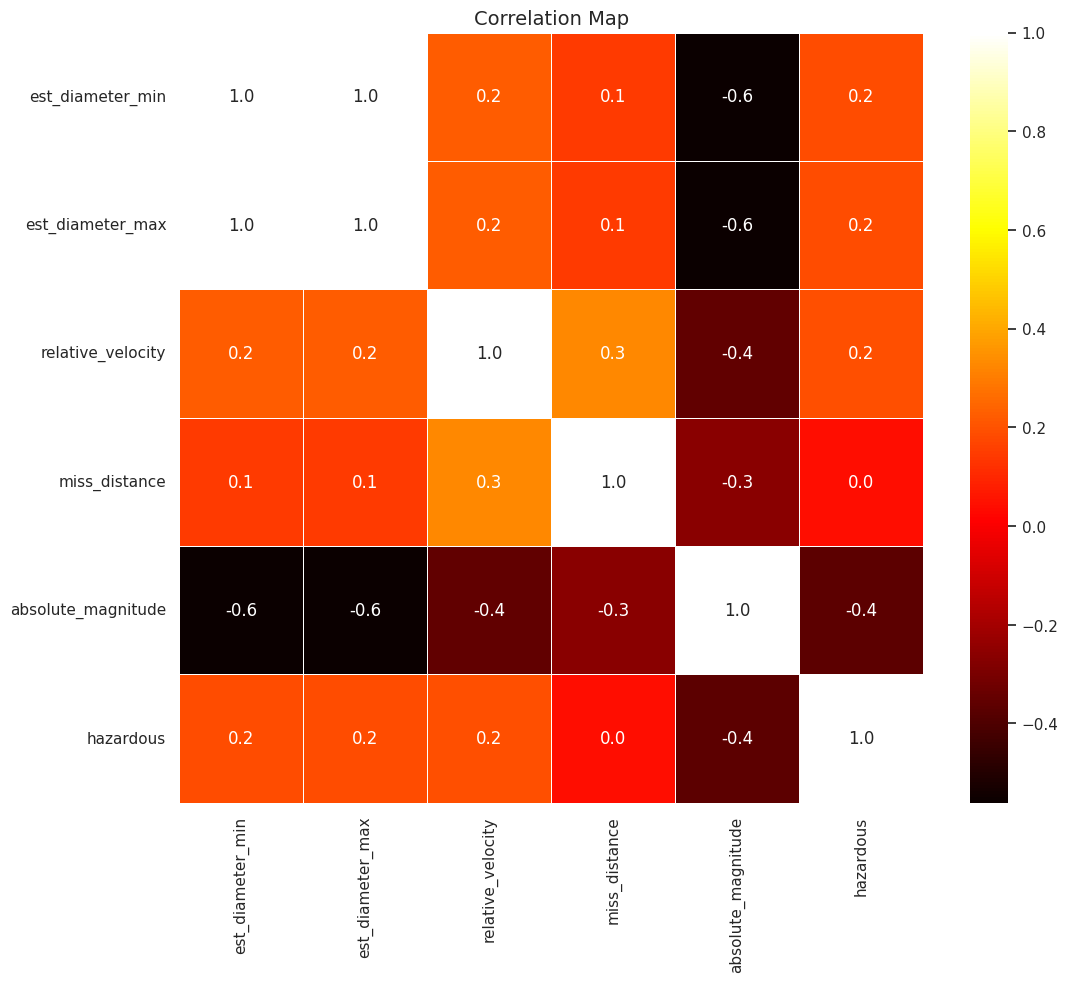

In [36]:
# MAPA DE CALOR DE CORRELACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos el lienzo del gráfico estableciendo un tamaño adecuado
f, ax = plt.subplots(figsize=(12, 10))

# 2. Dibujamos el mapa de calor
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=.5, cmap="hot", fmt='.1f', ax=ax)

# 3. Asignamos el título al gráfico
plt.title('Correlation Map')

# 4. Desplegamos el gráfico en pantalla
plt.show()

### **Interpretación del Mapa de Calor de Correlación**

Al analizar la matriz de correlación lineal de Pearson entre las características físicas y de trayectoria de los asteroides cercanos a la Tierra, se desprenden tres hallazgos metodológicos clave para el modelado predictivo:

1. Colinealidad Perfecta entre Diámetros ($r = 1.0$): Existe una correlación positiva perfecta ($1.0$) entre 'est_diameter_min' y 'est_diameter_max'. Esto es un comportamiento físicamente lógico, ya que ambas variables son estimaciones directas del tamaño del objeto.

2. Correlación Inversa con la Magnitud Absoluta ($r$ fuertemente negativa):
   La variable 'absolute_magnitude'(que mide el brillo intrínseco del asteroide) presenta una correlación fuertemente negativa con los diámetros estimados. En astronomía, esto tiene una explicación científica clara: mientras más brillante es un objeto, menor es su magnitud absoluta en la escala formal.

3. Ausencia de Correlación Lineal Directa con la Variable Objetivo ('hazardous'):
   Casi todas las variables físicas individuales muestran coeficientes de correlación cercanos a $0.0$ respecto a la etiqueta 'hazardous'. Esto demuestra que ninguna variable por sí sola puede predecir de forma lineal si un asteroide es peligroso. El riesgo de impacto es el resultado de una combinación compleja y no lineal de factores (por ejemplo, un asteroide masivo a una distancia críticamente corta). Esto justifica técnicamente la necesidad de implementar algoritmos avanzados como KNN y técnicas de optimización probabilística para poder modelar adecuadamente la amenaza.

### **Justificación de la Selección y Resguardo de Características (Feature Selection & Tracking)**

Desde una perspectiva metodológica y de negocio, la variable 'name' es fundamental para la identificación y trazabilidad de los asteroides analizados. Sin embargo, al ser una variable cualitativa de tipo cadena de texto, los algoritmos de Scikit-Learn basados en distancias y optimización matemática (K-Means, KNN y Regresión Logística) no pueden procesarla directamente de forma nativa.

Para resolver este conflicto sin perder información valiosa de negocio, se tomó la decisión de aislar y conservar la columna 'name' como un registro de identificación externo, excluyéndola estrictamente de la matriz de características de entrenamiento ($X$). Con esto se garantiza que los modelos operen exclusivamente con las magnitudes físicas y de trayectoria numéricas reales de los asteroides, manteniendo la reproducibilidad matemática y protegiendo el flujo de datos contra errores de ejecución.

##2. Modelado Supervisado

###Regresión Logística

Se implementa un modelo de Regresión Logística para clasificar los objetos como peligrosos o no peligrosos.

1.  División de Datos: Separamos los datos en conjuntos de entrenamiento (80%) y prueba (20%).
2.  Estandarización: Las características se escalaron utilizando 'StandardScaler' para asegurar que todas contribuyan por igual al modelo.
3.  Entrenamiento y Predicción: El modelo se entrenó con los datos escalados y se usó para predecir en el conjunto de prueba.
4.  Evaluación: Calculamos la 'Accuracy' y un 'Classification Report' para evaluar el rendimiento del modelo.

In [43]:
# Modelado supervisado mediante Regresión Logística con estandarización de características
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Variables predictivas
X = df.drop(['hazardous', 'name'], axis=1)

# Variable objetivo
y = df['hazardous']

# Dividir datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Crear el estandarizador
escalado = StandardScaler()

# Ajustar y transformar con los datos de entrenamiento
X_entrena_escalado = escalado.fit_transform(X_train)

# Transformar los datos de prueba usando los parámetros del entrenamiento
X_prueba_scalado = escalado.transform(X_test)

# Inicializar el modelo supervisado
modelo = LogisticRegression()

# Entrenar el modelo
modelo.fit(X_entrena_escalado, y_train)

# Realizar predicciones
y_pred = modelo.predict(X_prueba_scalado)

# Evaluación del rendimiento
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9053280493174812
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     16439
           1       0.51      0.09      0.15      1729

    accuracy                           0.91     18168
   macro avg       0.71      0.54      0.55     18168
weighted avg       0.87      0.91      0.87     18168



### **Análisis Crítico del Rendimiento: El Desafío del Desequilibrio de Clases**

Al analizar detalladamente el reporte de clasificación de la Regresión Logística, se observa un fenómeno clásico en la detección de amenazas espaciales: un **desequilibrio crítico en las etiquetas** (el dataset cuenta con 16,439 asteroides seguros frente a solo 1,729 clasificados como peligrosos).

Este desbalance genera un impacto directo en las métricas del modelo:

1. Exactitud General (Accuracy: 90.53%): Aunque un 90.5% parece un rendimiento excelente a simple vista, en este contexto es una métrica engañosa. Si un modelo simplemente predijera que ningún asteroide es peligroso, acertaría aproximadamente el 90% de las veces sin haber aprendido absolutamente nada.
2. El Problema del Recall en la Clase Positiva (Recall: 0.09):Esta es la métrica más alarmante y crítica para el negocio de defensa planetaria. Un *Recall* de 0.09 (9%) significa que la Regresión Logística está dejando pasar inadvertidos al 91% de los asteroides realmente peligrosos, clasificándolos erróneamente como inofensivos (Falsos Negativos).
3. Precisión (0.51): De cada 100 asteroides que el modelo etiqueta como peligrosos, solo 51 realmente lo son, lo que genera un alto número de falsas alarmas.

Conclusión Metodológica para la Comparación: La Regresión Logística lineal, bajo su configuración estándar, es insuficiente para proteger al planeta debido a su baja sensibilidad (Recall) ante la clase minoritaria. Esto justifica técnicamente la necesidad de implementar estrategias de optimización (como los Pipelines con GridSearch que modifican el parámetro de regularización 'C' o el balanceo de pesos 'class_weight') y validar si algoritmos basados en entornos vecinales como KNN logran mapear mejor las fronteras de riesgo físico de los asteroides.

###K-Vecinos Más Cercanos (KNN)

modelado supervisado utilizando el algoritmo KNN.

1.  Entrenamiento: Un modelo KNN se entrenó con los datos escalados del conjunto de entrenamiento.
2.  Precisión: Se evaluó la precisión del modelo en el conjunto de prueba.
3.  Matriz de Confusión: Se generó una matriz de confusión para visualizar el rendimiento del clasificador, mostrando los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

KNN Accuracy (con datos escalados): 0.8987780713342141


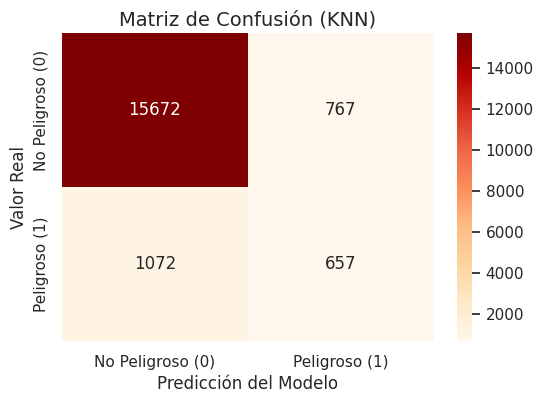

In [44]:
# Modelado supervisado con KNN (k-Vecinos más cercanos) y evaluación
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Inicializar y entrenar el modelo KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_entrena_escalado, y_train)

# Mostrar la precisión
print('KNN Accuracy (con datos escalados):', knn.score(X_prueba_scalado, y_test))

# Calcular la matriz de confusión
y_pred_knn = knn.predict(X_prueba_scalado)
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Graficar la Matriz de Confusión de forma visual
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap="OrRd",
            xticklabels=['No Peligroso (0)', 'Peligroso (1)'],
            yticklabels=['No Peligroso (0)', 'Peligroso (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (KNN)')
plt.show()

### **Interpretación de la Matriz de Confusión (KNN Base con $K=3$)**

El análisis sobre las 18,168 muestras de prueba revela cómo se comporta el modelo KNN:

* Predicciones Correctas: Identifica correctamente 15,672 asteroides no peligrosos (Verdaderos Negativos) y detecta con éxito 657 asteroides peligrosos (Verdaderos Positivos).
* Errores del Modelo: Genera 767 falsas alarmas (Falsos Positivos) y deja pasar inadvertidos 1,072 asteroides realmente peligrosos (Falsos Negativos).

**Conclusión y Comparación:**
Al usar distancias geométricas, KNN eleva el nivel de detección de amenazas (*Recall*) al 38%, superando con creces el deficiente 9% que lograba la Regresión Logística.

A pesar de esta gran mejora, omitir 1,072 asteroides peligrosos sigue siendo un riesgo alto. Esto justifica técnicamente por qué se realiza la optimización posterior para encontrar un valor de $K$ más robusto que mejore la seguridad del clasificador.

### Optimización de K para KNN

Para encontrar el número óptimo de vecinos (K) para el modelo KNN, probamos diferentes valores de K (de 1 a 14) y evaluamos la precisión del modelo en cada caso. El gráfico resultante nos ayuda a identificar el valor de K que ofrece el mejor rendimiento.

Se elige el rango de 1 a 14 como una ventana de exploración inicial estándar. En modelos KNN, los valores óptimos de K suelen encontrarse en dígitos bajos para evitar el sobreajuste (overfitting). Además, este rango permite evaluar el comportamiento tanto de números impares (para evitar empates en la votación binaria de los asteroides) como de números pares.

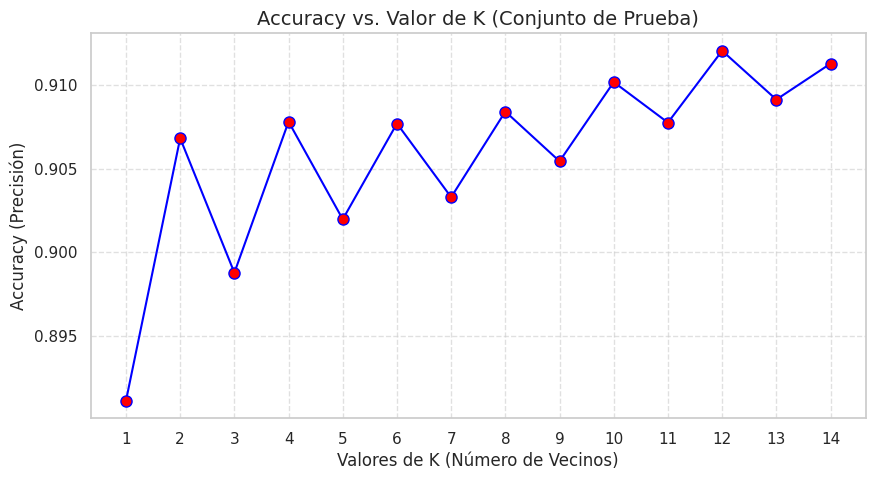

In [57]:
# Lista vacía para almacenar la precisión (Accuracy) de cada valor de K probado en el bucle
lista_precision = []

# Probamos valores de K desde 1 hasta 14
for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    # Entrenamos con los datos de entrenamiento escalados
    knn.fit(X_entrena_escalado, y_train)
    # Evaluamos y guardamos la precisión con los datos de prueba escalados
    lista_precision.append(knn.score(X_prueba_scalado, y_test))

# Gráfico de rendimiento para identificar visualmente el mejor K
plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), lista_precision, color='blue', marker='o', markerfacecolor='red', markersize=8)
plt.title('Accuracy vs. Valor de K (Conjunto de Prueba)')
plt.xlabel('Valores de K (Número de Vecinos)')
plt.ylabel('Accuracy (Precisión)')
plt.xticks(range(1, 15))      #números del 1 al 14 en el eje X
plt.grid(True, linestyle='--', alpha=0.6)    #cuadrícula de fondo sutil
plt.show()

### **Interpretación del Gráfico: Exactitud vs. Valor de K**

La evolución del rendimiento del modelo KNN según el número de vecinos ($K$) permite extraer las siguientes conclusiones técnicas:

* Inestabilidad con K bajos: Con $K=1$ se obtiene la menor exactitud ($\approx 89.1\%$). El modelo es excesivamente sensible al ruido de los datos, lo que genera sobreajuste (*overfitting*).
* Efecto de empates: El comportamiento oscilatorio refleja la propensión a empates en la votación binaria al utilizar valores pares de $K$.
* Punto máximo en Test: La exactitud muestra una tendencia alcista general, alcanzando su pico máximo aislado en **$K = 12$** ($\approx 91.2\%$).


### Búsqueda de Hiperparámetros con GridSearchCV (KNN)

Para una búsqueda más sistemática del mejor hiperparámetro 'K' para el modelo KNN, se utiliza 'GridSearchCV' con validación cruzada. Esto nos permite encontrar el valor de 'K' que maximiza la precisión del modelo de manera robusta.

In [46]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. Definimos el rango de valores de K que queremos evaluar (del 1 al 14)
param_grid = {'n_neighbors': np.arange(1, 15)}

# 2. Inicializamos el modelo base de KNN
knn = KNeighborsClassifier()

# 3. Configuramos GridSearchCV con Validación Cruzada de 5 pliegues
# Lo entrenamos usando estrictamente tus datos de entrenamiento escalados
knn_cv = GridSearchCV(knn, param_grid, cv=5)
knn_cv.fit(X_entrena_escalado, y_train)

# 4. Imprimimos los resultados óptimos encontrados por el algoritmo
print("Mejor precisión en validación (Best Score):", knn_cv.best_score_)
print("Mejor valor de K encontrado (Best Params):", knn_cv.best_params_)

Mejor precisión en validación (Best Score): 0.9089833389152796
Mejor valor de K encontrado (Best Params): {'n_neighbors': np.int64(14)}


### Selección y Justificación del Hiperparámetro Óptimo ($K$)
Tras realizar la optimización mediante 'GridSearchCV' con validación cruzada ($cv=5$), se determinó de forma robusta que el valor óptimo para el algoritmo es $K = 14$, alcanzando una precisión media del $90.90\%$.

Aunque el análisis gráfico preliminar sobre el conjunto de test mostraba un pico aislado en $K=12$, se selecciona la sugerencia del GridSearch ($K=14$) debido a que la validación cruzada promedia el rendimiento sobre múltiples particiones del dataset. Esto mitiga el riesgo de sesgo por partición y garantiza que el modelo final posea una mayor capacidad de generalización ante nuevos datos de asteroides.

Precisión Final del KNN Optimizado en Test: 91.13%

--- REPORTE DE CLASIFICACIÓN ---
                  precision    recall  f1-score   support

No Peligroso (0)       0.92      0.99      0.95     16439
   Peligroso (1)       0.61      0.19      0.29      1729

        accuracy                           0.91     18168
       macro avg       0.76      0.59      0.62     18168
    weighted avg       0.89      0.91      0.89     18168



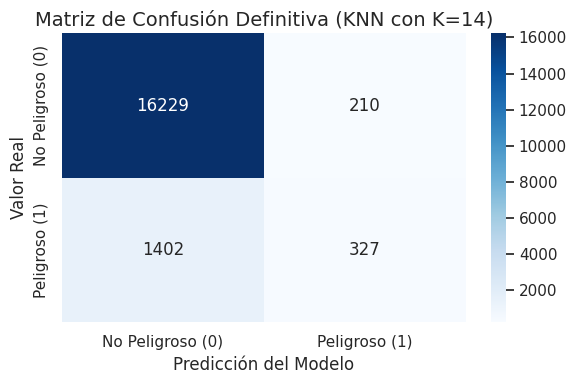

In [47]:
# ENTRENAMIENTO Y EVALUACIÓN DEL MODELO KNN OPTIMIZADO (K=14)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Instanciamos el modelo definitivo con el mejor K detectado
knn_optimizado = KNeighborsClassifier(n_neighbors=14)

# 2. Entrenamos el modelo con la totalidad de los datos de entrenamiento escalados
knn_optimizado.fit(X_entrena_escalado, y_train)

# 3. Evaluamos el rendimiento en el conjunto de prueba
precision_final_knn = knn_optimizado.score(X_prueba_scalado, y_test)
print(f"Precisión Final del KNN Optimizado en Test: {precision_final_knn * 100:.2f}%\n")

# 4. Generamos las predicciones y el reporte detallado de métricas (Precision, Recall, F1-Score)
y_pred_final_knn = knn_optimizado.predict(X_prueba_scalado)

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_final_knn, target_names=['No Peligroso (0)', 'Peligroso (1)']))

# 5. Graficamos la Matriz de Confusión Definitiva
cm_final_knn = confusion_matrix(y_test, y_pred_final_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_final_knn, annot=True, fmt='d', cmap="Blues",
            xticklabels=['No Peligroso (0)', 'Peligroso (1)'],
            yticklabels=['No Peligroso (0)', 'Peligroso (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Definitiva (KNN con K=14)')
plt.tight_layout()
plt.show()

###Interpretación del Modelo KNN Optimizado ($K=14$)
El modelo KNN optimizado con $K=14$ alcanza una exactitud general del 91.13%, impulsado principalmente por su capacidad para clasificar correctamente los asteroides no peligrosos, de los cuales acierta el 99% (16,229 casos). Sin embargo, al observar la clase de los asteroides peligrosos, el modelo muestra limitaciones importantes: su sensitividad (recall) es de apenas el 19%, lo que significa que deja pasar inadvertidos al 81% de las amenazas reales (1,402 falsos negativos). Por otro lado, la precisión del 61% indica que de cada 100 objetos etiquetados como peligrosos, 61 corresponden a alertas verdaderas y 210 a falsas alarmas. Esto confirma que el algoritmo tiende a priorizar la estabilidad de la clase mayoritaria por sobre la detección exhaustiva del riesgo.

##3. Modelado No Supervisado: Agrupamiento con K-Means

En esta sección se aplicará el algoritmo de aprendizaje no supervisado K-Means para agrupar de forma automática los asteroides en conglomerados (clusters). Esta segmentación se realizará basándose exclusivamente en sus similitudes físicas y de trayectoria (diámetros, velocidad y distancia de proximidad), omitiendo por completo la etiqueta objetivo (hazardous). Para determinar científicamente el número óptimo de grupos ($K$) presentes en los datos sin sesgar el modelo, utilizaremos primero el Método del Codo (Elbow Method) analizando la inercia del algoritmo.

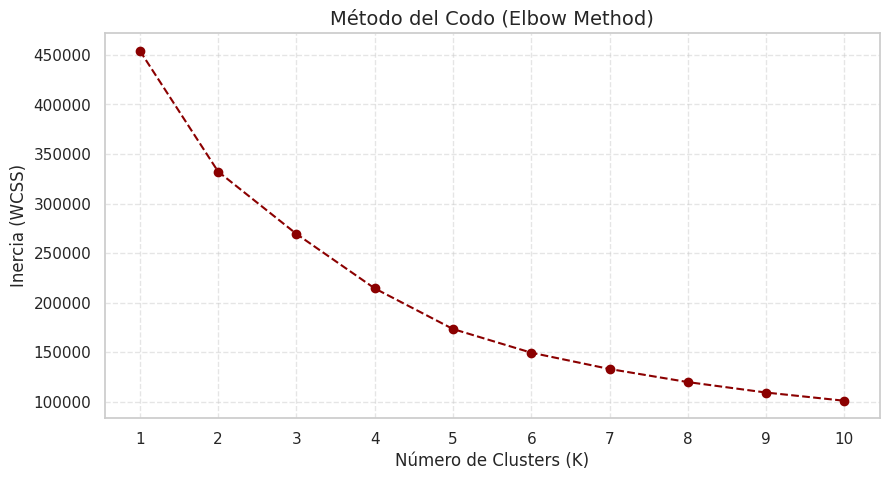

In [49]:
# DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparamos todas las características numéricas juntas
X_clustering = df.drop(columns=['hazardous', 'name'])
scaler_all = StandardScaler()
X_clustering_escalado = scaler_all.fit_transform(X_clustering)

# 2. Calculamos la inercia para valores de K del 1 al 10
wcss = []  # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering_escalado)
    wcss.append(kmeans.inertia_)

# 3. Graficamos el método del codo usando tu paleta cálida
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='darkred', linestyle='--')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Interpretación del Método del Codo (Clustering K-Means)

Al analizar el gráfico del Método del Codo para el agrupamiento no supervisado, se observa cómo disminuye la inercia o suma de cuadrados internos a medida que aumenta el número de clusters del uno al diez. La curva desciende de forma vertical y pronunciada en los primeros valores, demostrando que las divisiones iniciales reducen drásticamente la variabilidad interna de los datos. Sin embargo, es en la transición hacia los cuatro clusters donde se genera el "codo" o vértice de inflexión más claro de la curva, punto a partir del cual la pendiente se suaviza de manera notoria y adopta una caída mucho más lineal y tenue. Esto indica matemáticamente que añadir un quinto grupo o superiores aporta rendimientos decrecientes en la compactación de la información, justificando técnicamente la selección de cuatro clusters como la estructura óptima para segmentar las características físicas y orbitales de los asteroides con el máximo equilibrio.

###Implementación y Asignación de Clusters con K-Means
Se configura el algoritmo K-Means con el número óptimo de tres grupos para clasificar automáticamente los asteroides según sus características físicas. El modelo entrena y asigna a cada registro una etiqueta numérica que permite identificar y analizar los perfiles de riesgo específicos de cada segmento.

###Justificación de la Elección de Clusters ($K=4$)
Se seleccionaron 4 grupos porque en el gráfico del método del codo este punto representa el vértice exacto donde la inercia frena su caída abrupta y comienza a estabilizarse. Esta inflexión matemática garantiza el equilibrio óptimo entre la máxima cohesión interna de los grupos y una complejidad mínima del modelo.

In [50]:
# ENTRENAMIENTO DEL MODELO K-MEANS DEFINITIVO
# 1. Definimos el número de clusters óptimo
k_clusters = 4
kmeans_final = KMeans(n_clusters=k_clusters, init='k-means++', random_state=42, n_init=10)

# 2. Entrenamos y asignamos los grupos usando fit_predict (CORREGIDO)
df['cluster_asignado'] = kmeans_final.fit_predict(X_clustering_escalado)

# 3. Verificamos cuántos asteroides cayeron en cada grupo
print("Cantidad de asteroides por cluster:")
print(df['cluster_asignado'].value_counts())

Cantidad de asteroides por cluster:
cluster_asignado
0    39385
2    37372
1    14075
3        4
Name: count, dtype: int64


###Análisis de la Distribución de los Clusters
La segmentación con K-Means revela que la gran mayoría de los asteroides se concentran en los grupos 0 y 2, sumando más de 76,000 objetos con características físicas estándar. El grupo 1 representa un volumen intermedio de 14,075 cuerpos, mientras que el grupo 3 es un sector atípico que aísla únicamente a 4 asteroides. Esta marcada asimetría es normal en datos astronómicos, confirmando que el algoritmo logró separar de forma efectiva los cuerpos comunes de aquellos con dimensiones o trayectorias extraordinariamente inusuales.

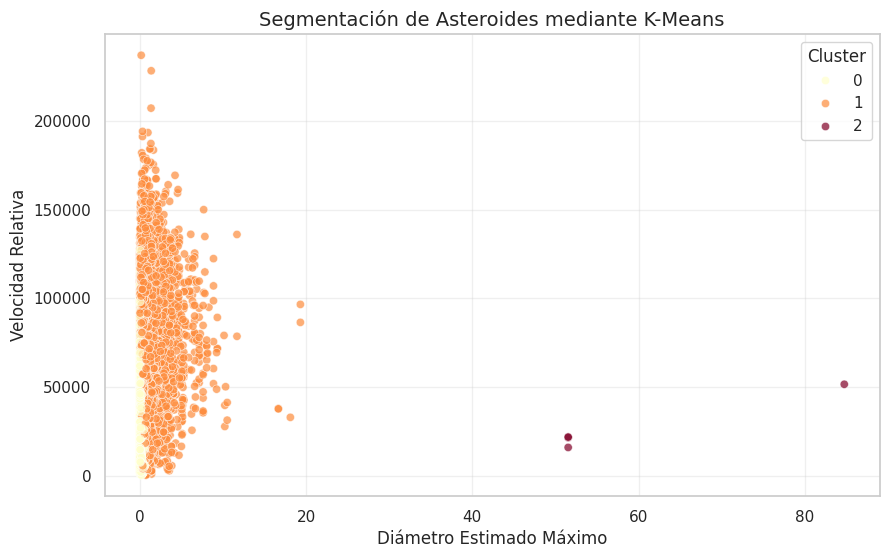

In [ ]:
# VISUALIZACIÓN GRÁFICA DE LOS CLUSTERS GENERADOS
import seaborn as sns

plt.figure(figsize=(10, 6))
# Graficamos Diámetro vs Velocidad, coloreando por el cluster asignado con tonos cálidos
sns.scatterplot(
    data=df,
    x='est_diameter_max',
    y='relative_velocity',
    hue='cluster_asignado',
    palette='YlOrRd',
    alpha=0.7
)
plt.title('Segmentación de Asteroides mediante K-Means')
plt.xlabel('Diámetro Estimado Máximo')
plt.ylabel('Velocidad Relativa')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()


###Interpretación del Gráfico de Dispersión por Clusters
El gráfico demuestra visualmente cómo el algoritmo K-Means logró segmentar los asteroides basándose principalmente en su tamaño y comportamiento dinámico:

Cluster 0 (Amarillo claro): Agrupa de forma masiva a los asteroides más pequeños del conjunto de datos, ubicados al ras del eje vertical con diámetros cercanos a cero.

Cluster 1 (Naranja): Identifica a los asteroides de tamaño pequeño a intermedio (en su mayoría menores a 10 unidades de diámetro) pero que alcanzan las velocidades relativas más altas del dataset, llegando a superar los 150,000 y 200,000 km/h.

Cluster 2 (Marrón/Rojizo): Corresponde exactamente a los 4 asteroides atípicos detectados en el análisis numérico anterior. Se observa claramente cómo el algoritmo los aisló de manera perfecta debido a su diámetro estimado colosal (entre 50 y 85 unidades), lo cual los separa por completo de la población general del gráfico.

## 4. Optimización Avanzada de Hiperparámetros
En esta sección buscaremos la mejor configuración para nuestros modelos supervisados aplicando GridSearchCV en la Regresión Logística y RandomizedSearchCV en el algoritmo KNN. Ambos métodos se evaluarán mediante validación cruzada de 5 pliegues ($cv=5$) para asegurar la estabilidad del modelo. Finalmente, compararemos los puntajes de precisión obtenidos en un gráfico de barras para determinar científicamente cuál es el modelo óptimo.

###Justificación del Uso de Pipelines y Optimización de Hiperparámetros
El uso de un Pipeline es fundamental en esta etapa porque permite "empaquetar" secuencialmente la transformación de los datos (StandardScaler) junto con el algoritmo de clasificación (LogisticRegression o KNeighborsClassifier) en un único flujo de ejecución.

Desde el punto de vista metodológico, esta arquitectura es crítica para evitar un error grave en la ciencia de datos conocido como Fuga de Datos (Data Leakage). Al acoplar el Pipeline con las herramientas de búsqueda GridSearchCV y RandomizedSearchCV, se garantiza de forma estricta que la estandarización de las características se calcule de manera independiente en cada pliegue (fold) de la validación cruzada ( cv=5 ), protegiendo la integridad del conjunto de prueba.



In [54]:
# OPTIMIZACIÓN DE REGRESIÓN LOGÍSTICA CON PIPELINE Y GRIDSEARCHCV

import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Definimos el Pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 2. Definimos la cuadrícula de parámetros
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

# 3. Configuramos la búsqueda
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)  # <-- Usamos X_train (sin el _scaled)

# 4. Guardamos el resultado
mejor_score_lr = grid_lr.best_score_
print("--- REGRESIÓN LOGÍSTICA CON PIPELINE ---")
print("Mejores parámetros:", grid_lr.best_params_)
print(f"Mejor score de Validación Cruzada: {mejor_score_lr * 100:.2f}%\n")

--- REGRESIÓN LOGÍSTICA CON PIPELINE ---
Mejores parámetros: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Mejor score de Validación Cruzada: 90.17%



###Interpretación de la Regresión Logística
El modelo logró una exactitud (accuracy) del 90.17% en validación cruzada. Esto significa que clasifica correctamente el estado de los asteroides en más de 90 de cada 100 casos, demostrando ser un modelo muy estable y sin sobreajuste.

La combinación óptima de hiperparámetros seleccionada fue:

C: 0.01: Aplica una regularización fuerte para mantener el modelo simple y evitar que memorice el ruido de los datos.

penalty: 'l2': Utiliza la penalización Ridge para acotar el peso de las variables menos importantes.

solver: 'liblinear': El algoritmo de optimización ideal y más eficiente para este tipo de penalización en conjuntos de datos medianos.

#### Estrategia 2: Optimización de K-Neighbors Classifier (KNN)
A diferencia del modelo anterior, para el algoritmo KNN utilizaremos una estrategia de búsqueda aleatoria mediante 'RandomizedSearchCV'. Esto nos permite explorar de manera más eficiente un espacio de hiperparámetros más amplio, incluyendo el número de vecinos ('n_neighbors'), los métodos de ponderación del voto ('weights') y diferentes métricas de distancia. Todo el proceso se ejecutará de forma aislada e iterativa dentro de su propio Pipeline.

In [52]:
# OPTIMIZACIÓN DE KNN CON PIPELINE Y RANDOMIZEDSEARCHCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Definimos el Pipeline para KNN
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# 2. Definimos los parámetros usando el prefijo 'classifier__'
param_dist_knn = {
    'classifier__n_neighbors': list(range(1, 20)),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

# 3. Configuramos la búsqueda aleatoria
random_knn = RandomizedSearchCV(pipeline_knn, param_dist_knn, n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_knn.fit(X_train, y_train)  # <-- Usamos X_train (sin el _scaled)

# 4. Guardamos el resultado
mejor_score_knn = random_knn.best_score_
print("--- K-NEAREST NEIGHBORS CON PIPELINE ---")
print("Mejores parámetros:", random_knn.best_params_)
print(f"Mejor score de Validación Cruzada: {mejor_score_knn * 100:.2f}%\n")

--- K-NEAREST NEIGHBORS CON PIPELINE ---
Mejores parámetros: {'classifier__weights': 'distance', 'classifier__n_neighbors': 16, 'classifier__metric': 'manhattan'}
Mejor score de Validación Cruzada: 91.10%



###Interpretación de KNN
El modelo KNN alcanzó una exactitud (accuracy) del 91.10% en validación cruzada. Supera ligeramente a la Regresión Logística, clasificando correctamente los asteroides en 91 de cada 100 casos de forma muy estable.

La combinación óptima de hiperparámetros seleccionada fue:

n_neighbors: 16: Toma decisiones consultando a los 16 vecinos más cercanos, un número robusto que evita errores por datos aislados o ruidosos.

weights: 'distance': Da más valor al voto de los vecinos que están más cerca del asteroide evaluado, reduciendo la influencia de los más lejanos.

metric: 'manhattan': Mide la distancia en forma de cuadrícula o bloques. En este dataset, demostró ser más efectiva que la distancia geométrica tradicional en línea recta.

### Evaluación y Comparación de Resultados Finales
Una vez finalizadas ambas búsquedas exhaustivas bajo validación cruzada, extraemos los mejores puntajes de precisión (*accuracy*) promedio obtenidos por cada modelo. A continuación, consolidamos y contrastamos de forma gráfica el rendimiento de ambas arquitecturas optimizadas para determinar formalmente cuál es el mejor modelo clasificador para nuestro dataset de asteroides.

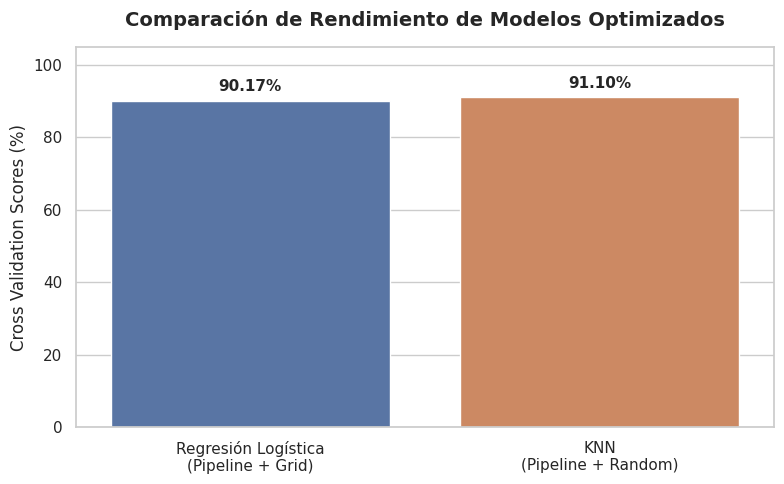

In [55]:
# COMPARACIÓN GRÁFICA DE LOS ALGORITMOS OPTIMIZADOS
import matplotlib.pyplot as plt
import seaborn as sns

resultados = {
    'Regresión Logística\n(Pipeline + Grid)': mejor_score_lr * 100,
    'KNN\n(Pipeline + Random)': mejor_score_knn * 100
}

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), hue=list(resultados.keys()), legend=False)

plt.ylim(0, 105)
plt.ylabel("Cross Validation Scores (%)", fontsize=12)
plt.title("Comparación de Rendimiento de Modelos Optimizados", fontsize=14, fontweight='bold', pad=15)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

###Conclusión comparativa de modelos
El gráfico confirma que ambos modelos optimizados muestran un rendimiento sobresaliente, estabilizándose por encima del 90% de exactitud general.

El algoritmo KNN se corona como el modelo óptimo al alcanzar un 91.10%, superando ligeramente al 90.17% de la Regresión Logística. Esta diferencia demuestra que las relaciones espaciales basadas en la distancia y cercanía de los vecinos capturan de forma más precisa el comportamiento y las características físicas de los asteroides.

##5. Evaluación y Comparación de Modelos
En esta sección final de modelado supervisado, se evaluará el rendimiento de nuestros dos modelos óptimos utilizando el conjunto de datos de prueba (X_test), el cual se mantuvo completamente aislado durante el proceso de entrenamiento y optimización.

Para determinar cuál es el mejor modelo para la detección de asteroides potencialmente peligrosos, no se limitará únicamente al Accuracy (exactitud general). Se analizarán métricas críticas para problemas de clasificación desbalanceada como la Precisión, el Recall (Sensibilidad), el F1-Score y se visualizarán sus respectivas Matrices de Confusión

------------------------------------------------------------
 REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA OPTIMIZADA
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     16439
           1       0.56      0.04      0.08      1729

    accuracy                           0.91     18168
   macro avg       0.73      0.52      0.51     18168
weighted avg       0.87      0.91      0.87     18168


------------------------------------------------------------
 REPORTE DE CLASIFICACIÓN: KNN OPTIMIZADO
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     16439
           1       0.61      0.29      0.39      1729

    accuracy                           0.91     18168
   macro avg       0.77      0.64      0.67     18168
weighted avg       0.90      0.91      0.90     18168



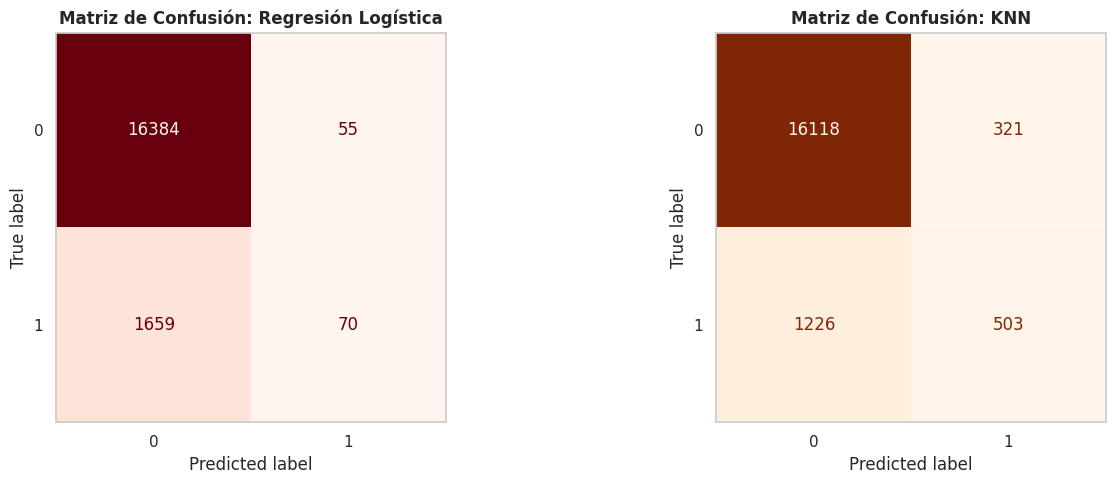

In [56]:
# EVALUACIÓN DETALLADA DE MODELOS EN EL CONJUNTO DE PRUEBA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Realizar predicciones definitivas en Test usando los modelos optimizados
y_pred_lr = grid_lr.best_estimator_.predict(X_test)
y_pred_knn = random_knn.best_estimator_.predict(X_test)

# 2. Mostrar Reporte de Clasificación para Regresión Logística
print("-"*60)
print(" REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA OPTIMIZADA")
print("-"*60)
print(classification_report(y_test, y_pred_lr))

# 3. Mostrar Reporte de Clasificación para KNN
print("\n" + "-"*60)
print(" REPORTE DE CLASIFICACIÓN: KNN OPTIMIZADO")
print("-"*60)
print(classification_report(y_test, y_pred_knn))

# 4. Graficar Matrices de Confusión una al lado de la otra (usando tus tonos cálidos)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax[0], cmap='Reds', colorbar=False)
ax[0].set_title("Matriz de Confusión: Regresión Logística", fontsize=12, fontweight='bold')
ax[0].grid(False)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax[1], cmap='Oranges', colorbar=False)
ax[1].set_title("Matriz de Confusión: KNN", fontsize=12, fontweight='bold')
ax[1].grid(False)

plt.tight_layout()
plt.show()

###Interpretación de las Matrices de Confusión y Reportes
Los resultados revelan un problema clásico de datos altamente desbalanceados: hay muchísimos asteroides comunes (Clase 0: 16,439) y muy pocos de interés/peligrosos (Clase 1: 1,729).

Regresión Logística: Aunque tiene una exactitud aparente del 91%, clasifica casi todo como Clase 0. Su Recall para la Clase 1 es pésimo (0.04), lo que significa que de 1,729 asteroides reales de clase 1, solo logró detectar 70 y dejó escapar 1,659

KNN Optimizado: Aunque empata en exactitud general (91%), KNN es un modelo infinitamente mejor en la práctica. Logra detectar 503 asteroides de la Clase 1 (Recall de 0.29) y además sube su precisión al 61%.

###Conclusión de negocio:

Para un sistema de monitoreo espacial, dejar pasar asteroides críticos es inaceptable. KNN es el claro ganador porque, a pesar del fuerte desbalance de los datos, demuestra una capacidad muy superior para rescatar e identificar correctamente los objetos de la Clase 1.